In [1]:
import json
import platform
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")   # ← 먼저 스타일 적용

# ---- 한글 폰트 설정 (반드시 sns.set_style 이후에!) ----
system_name = platform.system()
if system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

with open("../output/bus_data/route_zone_coverage.json", "r", encoding="utf-8") as f:
    bus_routes = json.load(f)

taxi_df = pd.read_csv("../output/jfk_zone_stats/jfk_zone_stats.csv")
print(f"버스 노선 수: {len(bus_routes)}")
print(f"택시 존 수: {taxi_df.shape[0]}")
taxi_df.head()

버스 노선 수: 8
택시 존 수: 261


,do_location_id,zone,borough,trip_count,avg_distance_mi,total_distance_mi,avg_fare,total_fare,fare_median
0,265,Outside of NYC,NaN,354243,29.729668,1.053153e+07,122.958378,43557144.77,111.90
1,230,Times Sq/Theatre District,Manhattan,67707,18.041472,1.221534e+06,87.399837,5917580.77,74.92
2,132,JFK Airport,Queens,49410,3.017214,1.490806e+05,26.481294,1308440.75,16.21
3,164,Midtown South,Manhattan,40269,17.294012,6.964126e+05,83.240878,3352026.92,70.43
4,216,South Ozone Park,Queens,39092,3.381641,1.321951e+05,17.553396,686197.35,16.70


In [2]:
covered_location_ids = set()
zone_route_count = {}  # 이 zone을 지나는 버스 노선이 몇 개인지

for route in bus_routes:
    for z in route["covered_zones"]:
        loc_id = z["location_id"]
        covered_location_ids.add(loc_id)
        zone_route_count[loc_id] = zone_route_count.get(loc_id, 0) + 1

print(f"버스가 커버하는 고유 zone 개수: {len(covered_location_ids)}")

버스가 커버하는 고유 zone 개수: 27


In [3]:
taxi_df["has_bus_route"] = taxi_df["do_location_id"].isin(covered_location_ids)
taxi_df["bus_route_count"] = taxi_df["do_location_id"].map(zone_route_count).fillna(0).astype(int)

taxi_df[["zone","borough","trip_count","has_bus_route","bus_route_count"]].head(10)

,zone,borough,trip_count,has_bus_route,bus_route_count
0,Outside of NYC,NaN,354243,False,0
1,Times Sq/Theatre District,Manhattan,67707,False,0
2,JFK Airport,Queens,49410,True,8
3,Midtown South,Manhattan,40269,False,0
4,South Ozone Park,Queens,39092,True,4
5,Baisley Park,Queens,33933,True,4
6,Clinton East,Manhattan,33924,False,0
7,Midtown North,Manhattan,28259,False,0
8,East Chelsea,Manhattan,27396,False,0
9,Williamsburg (North Side),Brooklyn,27181,False,0


In [4]:
coverage_summary = taxi_df.groupby("has_bus_route").agg(
    zone_count=("zone", "count"),
    total_trips=("trip_count", "sum"),
    avg_fare=("avg_fare", "mean")
).rename(index={True: "버스 커버됨", False: "버스 미커버"})

print(coverage_summary)

               zone_count  total_trips   avg_fare
has_bus_route                                    
버스 미커버                233      1942932  70.978972
버스 커버됨                 27       367623  30.245887


In [5]:
# Block 5 (수정)
top_n = 15
uncovered_top = (
    taxi_df[~taxi_df["has_bus_route"]]
    .sort_values("trip_count", ascending=False)
    .head(top_n)
)

print("JFK 출발 → 아래 zone 도착 트립 중, JFK 버스 노선이 커버하지 않는 상위 목적지")
uncovered_top[["zone","borough","trip_count","avg_distance_mi","avg_fare"]]

JFK 출발 → 아래 zone 도착 트립 중, JFK 버스 노선이 커버하지 않는 상위 목적지


,zone,borough,trip_count,avg_distance_mi,avg_fare
0,Outside of NYC,NaN,354243,29.729668,122.958378
1,Times Sq/Theatre District,Manhattan,67707,18.041472,87.399837
3,Midtown South,Manhattan,40269,17.294012,83.240878
6,Clinton East,Manhattan,33924,18.296455,82.477311
7,Midtown North,Manhattan,28259,18.097911,93.126834
8,East Chelsea,Manhattan,27396,18.298135,86.734914
9,Williamsburg (North Side),Brooklyn,27181,16.077446,71.981792
10,Midtown Center,Manhattan,26851,17.636712,89.248860
11,Murray Hill,Manhattan,26777,16.933776,75.528944
13,Midtown East,Manhattan,24670,17.244549,83.729326


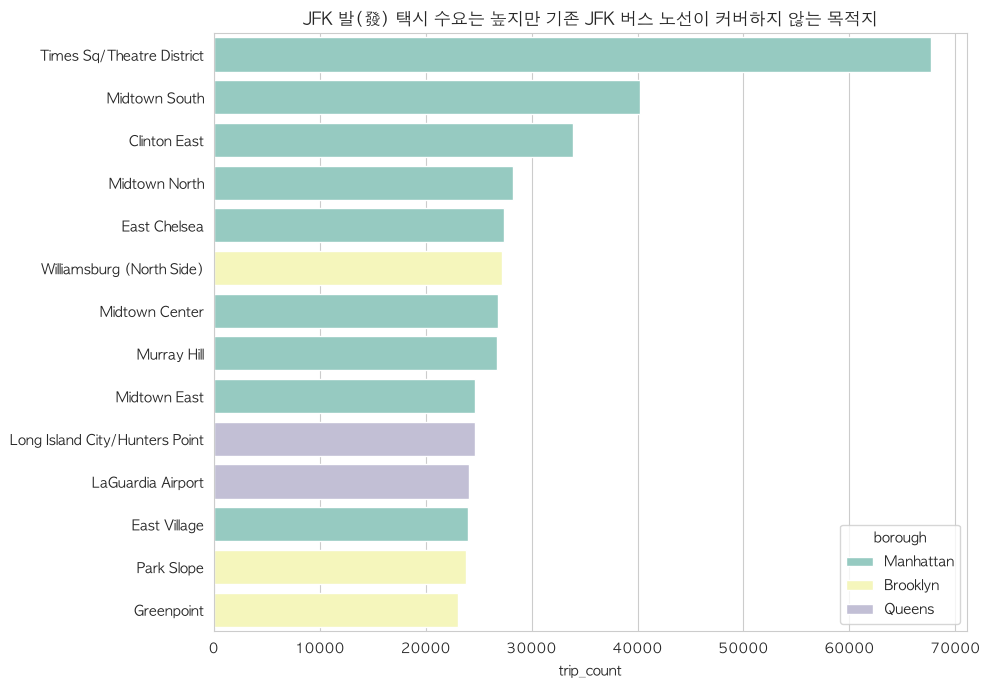

In [6]:
uncovered_clean = uncovered_top[~uncovered_top["zone"].isin(["Outside of NYC", "N/A"])]

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=uncovered_clean,
    y="zone", x="trip_count", hue="borough",
    dodge=False, ax=ax
)
# Block 6 제목 수정
ax.set_title("JFK 발(發) 택시 수요는 높지만 기존 JFK 버스 노선이 커버하지 않는 목적지")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

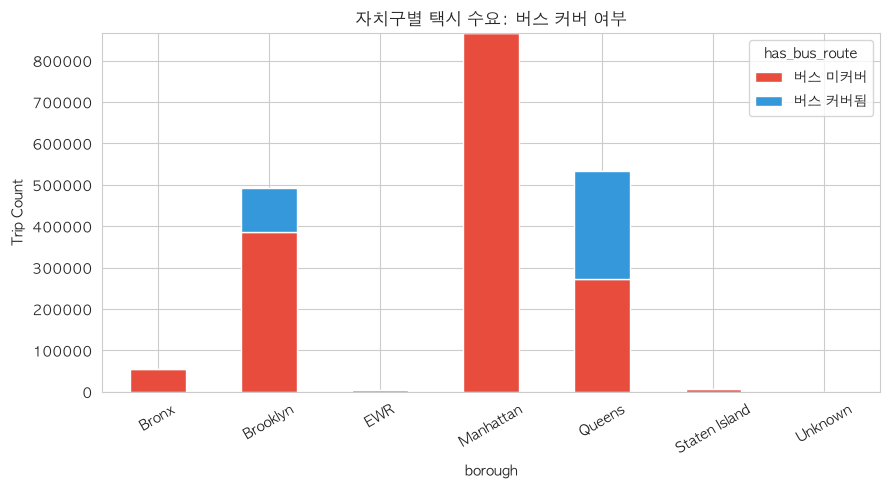

In [7]:
borough_compare = (
    taxi_df.groupby(["borough", "has_bus_route"])["trip_count"]
    .sum()
    .unstack(fill_value=0)
    .rename(columns={True: "버스 커버됨", False: "버스 미커버"})
)

fig, ax = plt.subplots(figsize=(9, 5))
borough_compare.plot(kind="bar", stacked=True, ax=ax, color=["#e74c3c", "#3498db"])
ax.set_title("자치구별 택시 수요: 버스 커버 여부")
ax.set_ylabel("Trip Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [8]:
route_candidates = uncovered_clean.copy()
route_candidates["demand_rank"] = range(1, len(route_candidates) + 1)

route_candidates_display = route_candidates[[
    "demand_rank", "zone", "borough", "trip_count", "avg_fare"
]].reset_index(drop=True)

print("=== 신규 버스 노선 검토 후보 (수요 기준 상위) ===")
route_candidates_display

=== 신규 버스 노선 검토 후보 (수요 기준 상위) ===


,demand_rank,zone,borough,trip_count,avg_fare
0,1,Times Sq/Theatre District,Manhattan,67707,87.399837
1,2,Midtown South,Manhattan,40269,83.240878
2,3,Clinton East,Manhattan,33924,82.477311
3,4,Midtown North,Manhattan,28259,93.126834
4,5,East Chelsea,Manhattan,27396,86.734914
5,6,Williamsburg (North Side),Brooklyn,27181,71.981792
6,7,Midtown Center,Manhattan,26851,89.248860
7,8,Murray Hill,Manhattan,26777,75.528944
8,9,Midtown East,Manhattan,24670,83.729326
9,10,Long Island City/Hunters Point,Queens,24655,64.478045


In [9]:
top3 = route_candidates_display.head(3)
print("우선 검토 대상 3곳:")
for _, row in top3.iterrows():
    print(f"- {row['zone']} ({row['borough']}): 연 {row['trip_count']:,}건, 평균요금 ${row['avg_fare']:.2f}")

# Block 9 주석 수정
print("""
※ 해석 시 주의사항 (정정):
1. 이 데이터는 pickup=JFK Airport로 고정된 트립들의 dropoff 분포입니다.
   즉 아래 후보들은 'JFK ↔ 특정 zone' 신규 노선 후보입니다.
2. 사용된 버스 데이터는 JFK 접근 노선 8개뿐이므로, 이 8개 노선 대비 갭 분석입니다.
3. 실제 노선 설계를 위해서는 각 zone의 위경도와 기존 도로망 정보가 추가로 필요합니다.
""")

우선 검토 대상 3곳:
- Times Sq/Theatre District (Manhattan): 연 67,707건, 평균요금 $87.40
- Midtown South (Manhattan): 연 40,269건, 평균요금 $83.24
- Clinton East (Manhattan): 연 33,924건, 평균요금 $82.48

※ 해석 시 주의사항 (정정):
1. 이 데이터는 pickup=JFK Airport로 고정된 트립들의 dropoff 분포입니다.
   즉 아래 후보들은 'JFK ↔ 특정 zone' 신규 노선 후보입니다.
2. 사용된 버스 데이터는 JFK 접근 노선 8개뿐이므로, 이 8개 노선 대비 갭 분석입니다.
3. 실제 노선 설계를 위해서는 각 zone의 위경도와 기존 도로망 정보가 추가로 필요합니다.



In [10]:
import geopandas as gpd

zones_gdf = gpd.read_file("../data/taxi_zones.geojson")

print(zones_gdf.columns.tolist())
zones_gdf.head(3)

['shape_area', 'locationid', 'shape_leng', 'zone', 'borough', 'geometry']


,shape_area,locationid,shape_leng,zone,borough,geometry
0,0.0007823067885,1,0.116357453189,Newark Airport,EWR,"MULTIPOLYGON (((-74.18445 40.695, -74.18449 40..."
1,0.00486634037837,2,0.43346966679,Jamaica Bay,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,0.000314414156821,3,0.0843411059012,Allerton/Pelham Gardens,Bronx,"MULTIPOLYGON (((-73.84793 40.87134, -73.84725 ..."


In [11]:
# 실제 컬럼명이 무엇이든 'LocationID'로 통일해서 이후 코드 재사용성 확보
id_col_candidates = ["LocationID", "location_id", "locationid"]
id_col = next((c for c in id_col_candidates if c in zones_gdf.columns), None)

if id_col is None:
    raise ValueError(f"LocationID 관련 컬럼을 못 찾았어요. 실제 컬럼: {zones_gdf.columns.tolist()}")

zones_gdf = zones_gdf.rename(columns={id_col: "LocationID"})
zones_gdf["LocationID"] = zones_gdf["LocationID"].astype(int)

# 좌표계 변환 (Socrata geojson은 보통 EPSG:4326으로 내려옴)
zones_gdf = zones_gdf.to_crs(epsg=2263)

print(f"zone 개수: {len(zones_gdf)}, 사용된 ID 컬럼: {id_col}")
zones_gdf[["LocationID"]].head()

zone 개수: 263, 사용된 ID 컬럼: locationid


,LocationID
0,1
1,2
2,3
3,4
4,5


In [12]:
# taxi_df, covered_location_ids, zone_route_count는 이전 블록에서 이미 만든 상태라고 가정
merged_gdf = zones_gdf.merge(
    taxi_df, left_on="LocationID", right_on="do_location_id", how="left"
)

merged_gdf["trip_count"] = merged_gdf["trip_count"].fillna(0)
merged_gdf["has_bus_route"] = merged_gdf["has_bus_route"].fillna(False)

print(f"매칭된 zone 수: {merged_gdf['do_location_id'].notna().sum()} / {len(merged_gdf)}")

매칭된 zone 수: 258 / 263


findfont: Failed to find font weight bold, now using 400.
/Users/yong/PycharmProjects/softeer_DE_w4_team2_wiki/.venv/lib/python3.14/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 9992 (\N{AIRPLANE}) missing from font(s) AppleGothic.
  ax.figure.canvas.draw_idle()
/var/folders/9q/ffxr24bs7cv3nlxks2qstv5r0000gn/T/ipykernel_22975/3025103582.py:67: UserWarning: Glyph 9992 (\N{AIRPLANE}) missing from font(s) AppleGothic.
  plt.savefig("../output/jfk_bus_gap_map.png", dpi=150, bbox_inches="tight")
/Users/yong/PycharmProjects/softeer_DE_w4_team2_wiki/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9992 (\N{AIRPLANE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


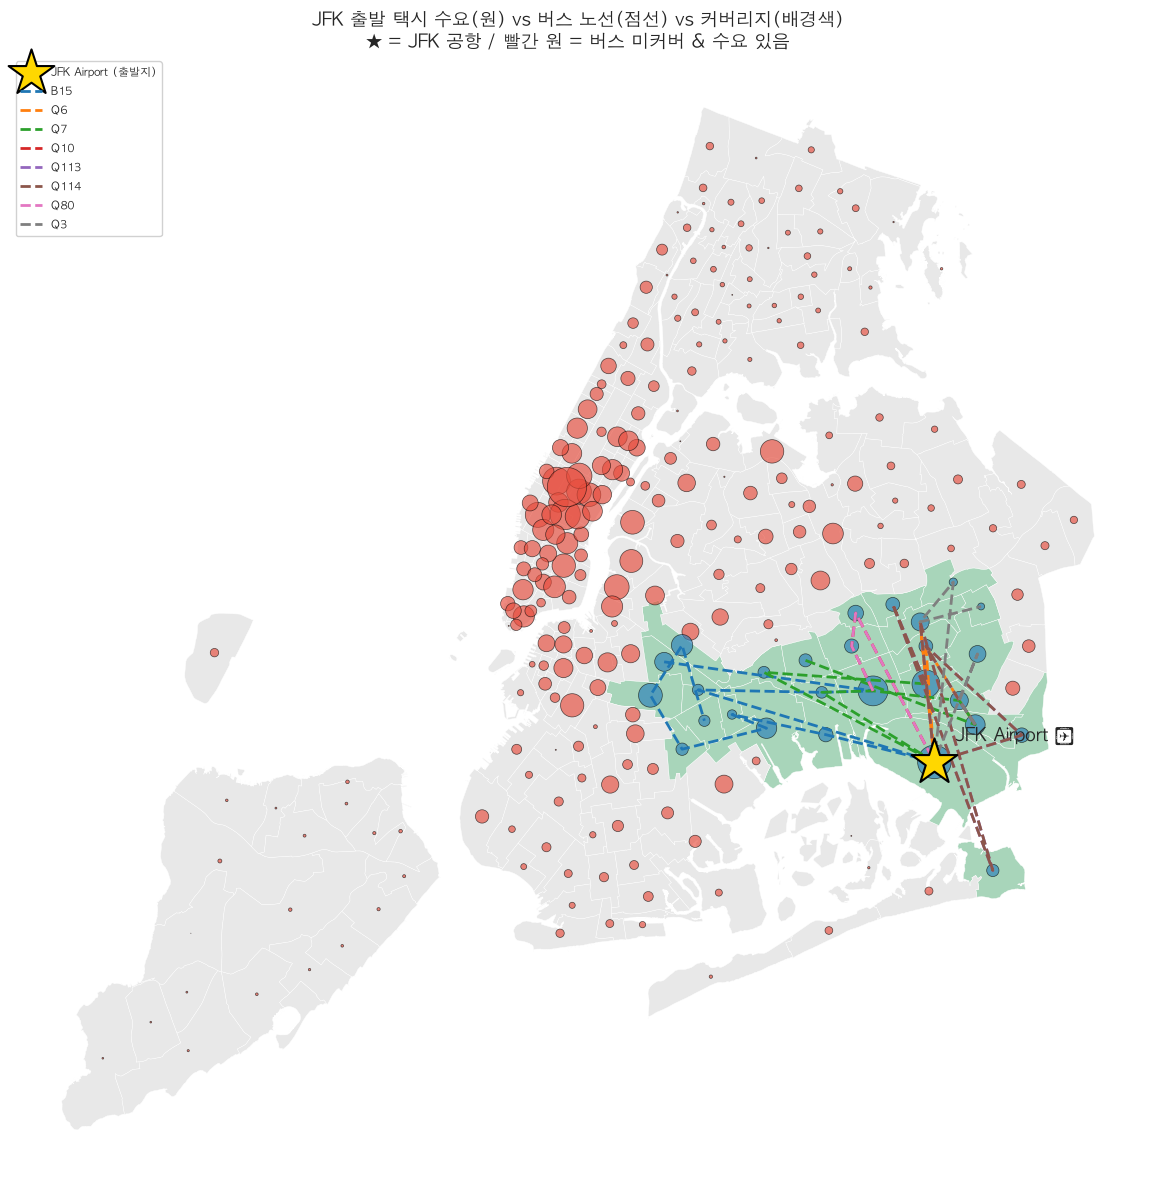

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

# ① 배경: 버스 커버 여부로 zone 색칠
merged_gdf.plot(
    ax=ax,
    color=merged_gdf["has_bus_route"].map({True: "#a8d5ba", False: "#e8e8e8"}),
    edgecolor="white",
    linewidth=0.3
)

# ② 택시 수요 버블
merged_gdf["centroid"] = merged_gdf.geometry.centroid
demand_zones = merged_gdf[merged_gdf["trip_count"] > 0].copy()
sizes = (demand_zones["trip_count"] / demand_zones["trip_count"].max()) * 800

ax.scatter(
    demand_zones.centroid.x, demand_zones.centroid.y,
    s=sizes,
    c=demand_zones["has_bus_route"].map({True: "#2980b9", False: "#e74c3c"}),
    alpha=0.65, edgecolor="black", linewidth=0.5, zorder=3
)

# ③ 출발지(JFK) 강조 — 별 마커로 눈에 띄게
JFK_LOCATION_ID = 132
jfk_row = merged_gdf[merged_gdf["LocationID"] == JFK_LOCATION_ID]

if not jfk_row.empty:
    jfk_x, jfk_y = jfk_row.centroid.x.values[0], jfk_row.centroid.y.values[0]
    ax.scatter(
        jfk_x, jfk_y,
        marker="*", s=1200, c="gold", edgecolor="black", linewidth=1.5,
        zorder=5, label="JFK Airport (출발지)"
    )
    ax.annotate(
        "JFK Airport ✈", (jfk_x, jfk_y),
        textcoords="offset points", xytext=(15, 15),
        fontsize=13, fontweight="bold"
    )
else:
    print("경고: JFK Airport(LocationID=132)를 찾지 못했어요. merged_gdf의 LocationID 목록을 확인하세요.")

# ④ 버스 노선을 선으로 표시 (노선별 다른 색)
from shapely.geometry import LineString

route_colors = plt.get_cmap("tab10")

for i, route in enumerate(bus_routes):
    loc_ids = [z["location_id"] for z in route["covered_zones"]]
    route_zones = merged_gdf[merged_gdf["LocationID"].isin(loc_ids)]
    if len(route_zones) >= 2:
        line = LineString(list(zip(route_zones.centroid.x, route_zones.centroid.y)))
        gpd.GeoSeries([line], crs=merged_gdf.crs).plot(
            ax=ax, color=route_colors(i % 10), linewidth=2,
            linestyle="--", label=f"{route['route_name']}", zorder=4
        )

ax.set_title(
    "JFK 출발 택시 수요(원) vs 버스 노선(점선) vs 커버리지(배경색)\n"
    "★ = JFK 공항 / 빨간 원 = 버스 미커버 & 수요 있음",
    fontsize=13
)
ax.set_axis_off()
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig("../output/jfk_bus_gap_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
from shapely.geometry import LineString

route_lines = []
for route in bus_routes:
    loc_ids = [z["location_id"] for z in route["covered_zones"]]
    route_zones = merged_gdf[merged_gdf["LocationID"].isin(loc_ids)].copy()
    if len(route_zones) >= 2:
        # 주의: covered_zones 리스트 순서 = 실제 도로 경로 순서가 아닐 수 있음
        # 여기서는 "이 노선이 대략 어느 zone들을 지나는지"를 보여주는 근사 표현임
        coords = list(zip(route_zones.centroid.x, route_zones.centroid.y))
        route_lines.append({"route_id": route["route_id"], "geometry": LineString(coords)})

routes_gdf = gpd.GeoDataFrame(route_lines, crs=merged_gdf.crs)
routes_gdf.plot(ax=ax, color="#2c3e50", linewidth=1.2, linestyle="--", alpha=0.7)

plt.savefig("../output/jfk_bus_gap_map.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>